## Notebook 6 — Model Comparison
---
LSTM vs VAR vs Prophet across all 10 MEVs for India.

What this notebook does:
- Loads LSTM results from Notebook 5 (pkl files)
- Reruns VAR and Prophet on the same test set (last 5 years) for fair comparison
- Computes RMSE and MAE for all three models per MEV
- Produces side-by-side comparison table and plots
- Declares a winner per MEV

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

print('Libraries loaded')

Libraries loaded


**Config — must match Notebook 5**

In [14]:
TARGET_COUNTRY      = 'India'
TEST_SIZE           = 5
SEQ_LENGTH          = 5

# Paste your Granger-significant countries from Notebook 3
important_countries = ['Bangladesh',
 'Eswatini, Kingdom of',
 'Marshall Islands, Republic of the',
 'Nepal',
 'Nicaragua',
 'Philippines',
 'Puerto Rico',
 'Somalia',
 'Tuvalu']   # ← update with your output

ALL_MEVS = [
    'GDP', 'Inflation', 'Unemployment rate', 'Current Balance',
    'Fiscal Balance', 'Debt', 'Investment', 'GNS', 'Export', 'Import'
]

**Load LSTM results from Notebook 5**

In [15]:
with open('lstm_models/results.pkl', 'rb') as f:
    lstm_results = pickle.load(f)

with open('lstm_models/forecasts.pkl', 'rb') as f:
    lstm_forecasts = pickle.load(f)

print('LSTM results loaded for MEVs:', list(lstm_results.keys()))

LSTM results loaded for MEVs: ['GDP', 'Inflation', 'Unemployment rate', 'Current Balance', 'Fiscal Balance', 'Debt', 'Investment', 'GNS', 'Export', 'Import']


**Load and prepare data — same pipeline as Notebook 5**

In [16]:
df = pd.read_csv('data.csv')

df_long = pd.melt(df, id_vars=['COUNTRY', 'INDICATOR', 'FREQUENCY'],
                  var_name='year', value_name='mev_value')
df_long['mev_value'] = pd.to_numeric(df_long['mev_value'], errors='coerce')
df_long['year']      = pd.to_numeric(df_long['year'],      errors='coerce')
df_long = df_long.dropna(subset=['mev_value'])

def change_names(row):
    ind = row['INDICATOR']
    if ind == 'Gross domestic product (GDP), Constant prices, Percent change':
        return 'GDP'
    elif ind == 'All Items, Consumer price index (CPI), Period average, percent change':
        return 'Inflation'
    elif ind == 'Current account balance (credit less debit), Percent of GDP':
        return 'Current Balance'
    elif ind == 'Gross national savings, Percent of GDP':
        return 'GNS'
    elif ind == 'Imports of goods and services, Volume, Cost insurance freight (CIF), Percent change':
        return 'Import'
    elif ind == 'Gross capital formation, Percent of GDP':
        return 'Investment'
    elif ind == 'Exports of goods and services, Volume, Free on board (FOB), Percent change':
        return 'Export'
    elif ind == 'Gross debt, General government, Percent of GDP':
        return 'Debt'
    elif ind == 'Structural balance, General government, Percent':
        return 'Fiscal Balance'
    elif ind == 'Unemployment rate':
        return 'Unemployment rate'
    else:
        return 'Other'

df_long['mev_name'] = df_long.apply(change_names, axis=1)
df_long = df_long[df_long['mev_name'] != 'Other']
print('Data loaded — shape:', df_long.shape)

Data loaded — shape: (47216, 6)


In [17]:
def make_pivot(df_long, mev, countries):
    """Return (year x country) pivot filtered to given countries."""
    subset = df_long[df_long['mev_name'] == mev]
    pivot  = pd.pivot_table(subset, index='year', columns='COUNTRY',
                            values='mev_value', fill_value=np.nan)
    available = [c for c in countries if c in pivot.columns]
    pivot = pivot[available].ffill().bfill().dropna()
    return pivot

**Run VAR on same test set — one per MEV**

In [18]:
var_results   = {}
var_forecasts = {}

for mev in ALL_MEVS:
    print(f'\nVAR — {mev}')

    countries = [TARGET_COUNTRY] + important_countries
    pivot     = make_pivot(df_long, mev, countries)

    if TARGET_COUNTRY not in pivot.columns or len(pivot) < TEST_SIZE + 3:
        print(f'  ⚠️  Skipping — insufficient data')
        continue

    # Split — train on everything before test window
    train = pivot.iloc[:-TEST_SIZE]
    test  = pivot.iloc[-TEST_SIZE:]
    y_actual = test[TARGET_COUNTRY].values

    y_pred = []
    df_rolling = train.copy()

    for step in range(TEST_SIZE):
        df_diff = df_rolling.diff().dropna()

        nobs      = len(df_diff)
        n_eq      = df_diff.shape[1]
        max_lag   = max(1, int((nobs - n_eq) / n_eq))
        use_lag   = min(1, max_lag)

        try:
            var_model  = VAR(df_diff)
            var_fitted = var_model.fit(use_lag)
            fc         = var_fitted.forecast(y=df_diff.values, steps=1)
            df_fc      = pd.DataFrame(fc, columns=df_rolling.columns)
            fc_val     = df_rolling[TARGET_COUNTRY].iloc[-1] + df_fc[TARGET_COUNTRY].values[0]
        except Exception as e:
            print(f'  VAR step {step+1} failed: {e} — using last value')
            fc_val = df_rolling[TARGET_COUNTRY].iloc[-1]

        y_pred.append(fc_val)

        # Append actual next row to rolling window for next step
        next_row        = test.iloc[[step]].copy()
        df_rolling      = pd.concat([df_rolling, next_row])

    y_pred = np.array(y_pred)
    rmse   = np.sqrt(mean_squared_error(y_actual, y_pred))
    mae    = mean_absolute_error(y_actual, y_pred)

    var_results[mev]   = {'RMSE': round(rmse, 4), 'MAE': round(mae, 4)}
    var_forecasts[mev] = {'actual': y_actual, 'predicted': y_pred}

    print(f'  RMSE: {rmse:.4f}  MAE: {mae:.4f}')


VAR — GDP
  RMSE: 4.1396  MAE: 3.5093

VAR — Inflation
  RMSE: 2.2955  MAE: 2.2651

VAR — Unemployment rate
  RMSE: 1.4645  MAE: 0.8121

VAR — Current Balance
  RMSE: 1.3976  MAE: 1.1003

VAR — Fiscal Balance
  RMSE: 0.5958  MAE: 0.4780

VAR — Debt
  RMSE: 8.2810  MAE: 4.7003

VAR — Investment
  RMSE: 1.1535  MAE: 1.0516

VAR — GNS
  RMSE: 0.9411  MAE: 0.9164

VAR — Export
  RMSE: 11.3416  MAE: 8.5680

VAR — Import
  RMSE: 8.6286  MAE: 8.0831


/home/hardikgogia/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/hardikgogia/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/hardikgogia/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/hardikgogia/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarni

**Run Prophet on same test set — one per MEV**

In [19]:
prophet_results   = {}
prophet_forecasts = {}

for mev in ALL_MEVS:
    print(f'\nProphet — {mev}')

    pivot = make_pivot(df_long, mev, [TARGET_COUNTRY])

    if TARGET_COUNTRY not in pivot.columns or len(pivot) < TEST_SIZE + 3:
        print(f'  ⚠️  Skipping — insufficient data')
        continue

    train    = pivot[[TARGET_COUNTRY]].iloc[:-TEST_SIZE].reset_index()
    y_actual = pivot[TARGET_COUNTRY].iloc[-TEST_SIZE:].values

    train.columns = ['ds', 'y']
    train['ds']   = pd.to_datetime(train['ds'], format='%Y')

    try:
        m      = Prophet(seasonality_mode='multiplicative')
        m.fit(train)
        future   = m.make_future_dataframe(periods=TEST_SIZE, freq='YE')
        forecast = m.predict(future)
        y_pred   = forecast['yhat'].iloc[-TEST_SIZE:].values
    except Exception as e:
        print(f'  Prophet failed: {e}')
        continue

    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mae  = mean_absolute_error(y_actual, y_pred)

    prophet_results[mev]   = {'RMSE': round(rmse, 4), 'MAE': round(mae, 4)}
    prophet_forecasts[mev] = {'actual': y_actual, 'predicted': y_pred}

    print(f'  RMSE: {rmse:.4f}  MAE: {mae:.4f}')

13:36:18 - cmdstanpy - INFO - Chain [1] start processing
13:36:18 - cmdstanpy - INFO - Chain [1] done processing
13:36:18 - cmdstanpy - INFO - Chain [1] start processing
13:36:18 - cmdstanpy - INFO - Chain [1] done processing
13:36:18 - cmdstanpy - INFO - Chain [1] start processing



Prophet — GDP
  RMSE: 5.8234  MAE: 5.5694

Prophet — Inflation
  RMSE: 2.1000  MAE: 1.7880

Prophet — Unemployment rate


13:36:18 - cmdstanpy - INFO - Chain [1] done processing
13:36:18 - cmdstanpy - INFO - Chain [1] start processing
13:36:18 - cmdstanpy - INFO - Chain [1] done processing
13:36:19 - cmdstanpy - INFO - Chain [1] start processing
13:36:19 - cmdstanpy - INFO - Chain [1] done processing
13:36:19 - cmdstanpy - INFO - Chain [1] start processing


  RMSE: 2.0110  MAE: 1.9931

Prophet — Current Balance
  RMSE: 0.6809  MAE: 0.6499

Prophet — Fiscal Balance
  RMSE: 1.5501  MAE: 1.5196

Prophet — Debt


13:36:19 - cmdstanpy - INFO - Chain [1] done processing
13:36:19 - cmdstanpy - INFO - Chain [1] start processing
13:36:19 - cmdstanpy - INFO - Chain [1] done processing
13:36:19 - cmdstanpy - INFO - Chain [1] start processing


  RMSE: 6.4712  MAE: 6.0399

Prophet — Investment
  RMSE: 2.7324  MAE: 2.4866

Prophet — GNS


13:36:19 - cmdstanpy - INFO - Chain [1] done processing
13:36:19 - cmdstanpy - INFO - Chain [1] start processing
13:36:19 - cmdstanpy - INFO - Chain [1] done processing
13:36:19 - cmdstanpy - INFO - Chain [1] start processing
13:36:19 - cmdstanpy - INFO - Chain [1] done processing


  RMSE: 9.3501  MAE: 8.4165

Prophet — Export
  RMSE: 4.9550  MAE: 4.1438

Prophet — Import
  RMSE: 5.5533  MAE: 5.0683


**Comparison Table — RMSE and MAE**

In [20]:
rows = []

for mev in ALL_MEVS:
    row = {'MEV': mev}

    row['LSTM RMSE']    = lstm_results.get(mev,    {}).get('RMSE', np.nan)
    row['VAR RMSE']     = var_results.get(mev,     {}).get('RMSE', np.nan)
    row['Prophet RMSE'] = prophet_results.get(mev, {}).get('RMSE', np.nan)

    row['LSTM MAE']    = lstm_results.get(mev,    {}).get('MAE', np.nan)
    row['VAR MAE']     = var_results.get(mev,     {}).get('MAE', np.nan)
    row['Prophet MAE'] = prophet_results.get(mev, {}).get('MAE', np.nan)

    # Winner — model with lowest RMSE
    rmse_vals = {
        'LSTM'   : row['LSTM RMSE'],
        'VAR'    : row['VAR RMSE'],
        'Prophet': row['Prophet RMSE']
    }
    valid = {k: v for k, v in rmse_vals.items() if not np.isnan(v)}
    row['Winner'] = min(valid, key=valid.get) if valid else 'N/A'

    rows.append(row)

comparison_df = pd.DataFrame(rows).set_index('MEV')

print('\n=== Model Comparison — India ===')
print(comparison_df.to_string())
comparison_df


=== Model Comparison — India ===
                   LSTM RMSE  VAR RMSE  Prophet RMSE  LSTM MAE  VAR MAE  Prophet MAE   Winner
MEV                                                                                          
GDP                   5.9911    4.1396        5.8234    5.7848   3.5093       5.5694      VAR
Inflation             2.5197    2.2955        2.1000    2.1214   2.2651       1.7880  Prophet
Unemployment rate     0.2522    1.4645        2.0110    0.2244   0.8121       1.9931     LSTM
Current Balance       3.2531    1.3976        0.6809    3.2145   1.1003       0.6499  Prophet
Fiscal Balance        1.3154    0.5958        1.5501    1.1322   0.4780       1.5196      VAR
Debt                 14.5963    8.2810        6.4712   14.5878   4.7003       6.0399  Prophet
Investment            6.7475    1.1535        2.7324    6.7270   1.0516       2.4866      VAR
GNS                   2.2540    0.9411        9.3501    2.1776   0.9164       8.4165      VAR
Export                8.92

,LSTM RMSE,VAR RMSE,Prophet RMSE,LSTM MAE,VAR MAE,Prophet MAE,Winner
MEV,,,,,,,
GDP,5.9911,4.1396,5.8234,5.7848,3.5093,5.5694,VAR
Inflation,2.5197,2.2955,2.1000,2.1214,2.2651,1.7880,Prophet
Unemployment rate,0.2522,1.4645,2.0110,0.2244,0.8121,1.9931,LSTM
Current Balance,3.2531,1.3976,0.6809,3.2145,1.1003,0.6499,Prophet
Fiscal Balance,1.3154,0.5958,1.5501,1.1322,0.4780,1.5196,VAR
Debt,14.5963,8.2810,6.4712,14.5878,4.7003,6.0399,Prophet
Investment,6.7475,1.1535,2.7324,6.7270,1.0516,2.4866,VAR
GNS,2.2540,0.9411,9.3501,2.1776,0.9164,8.4165,VAR
Export,8.9222,11.3416,4.9550,8.2888,8.5680,4.1438,Prophet


In [21]:
# Summary — how many MEVs each model wins
winner_counts = comparison_df['Winner'].value_counts()
print('\nWins per model:')
print(winner_counts.to_string())


Wins per model:
Winner
Prophet    5
VAR        4
LSTM       1


**Side-by-side forecast plots — all 3 models per MEV**

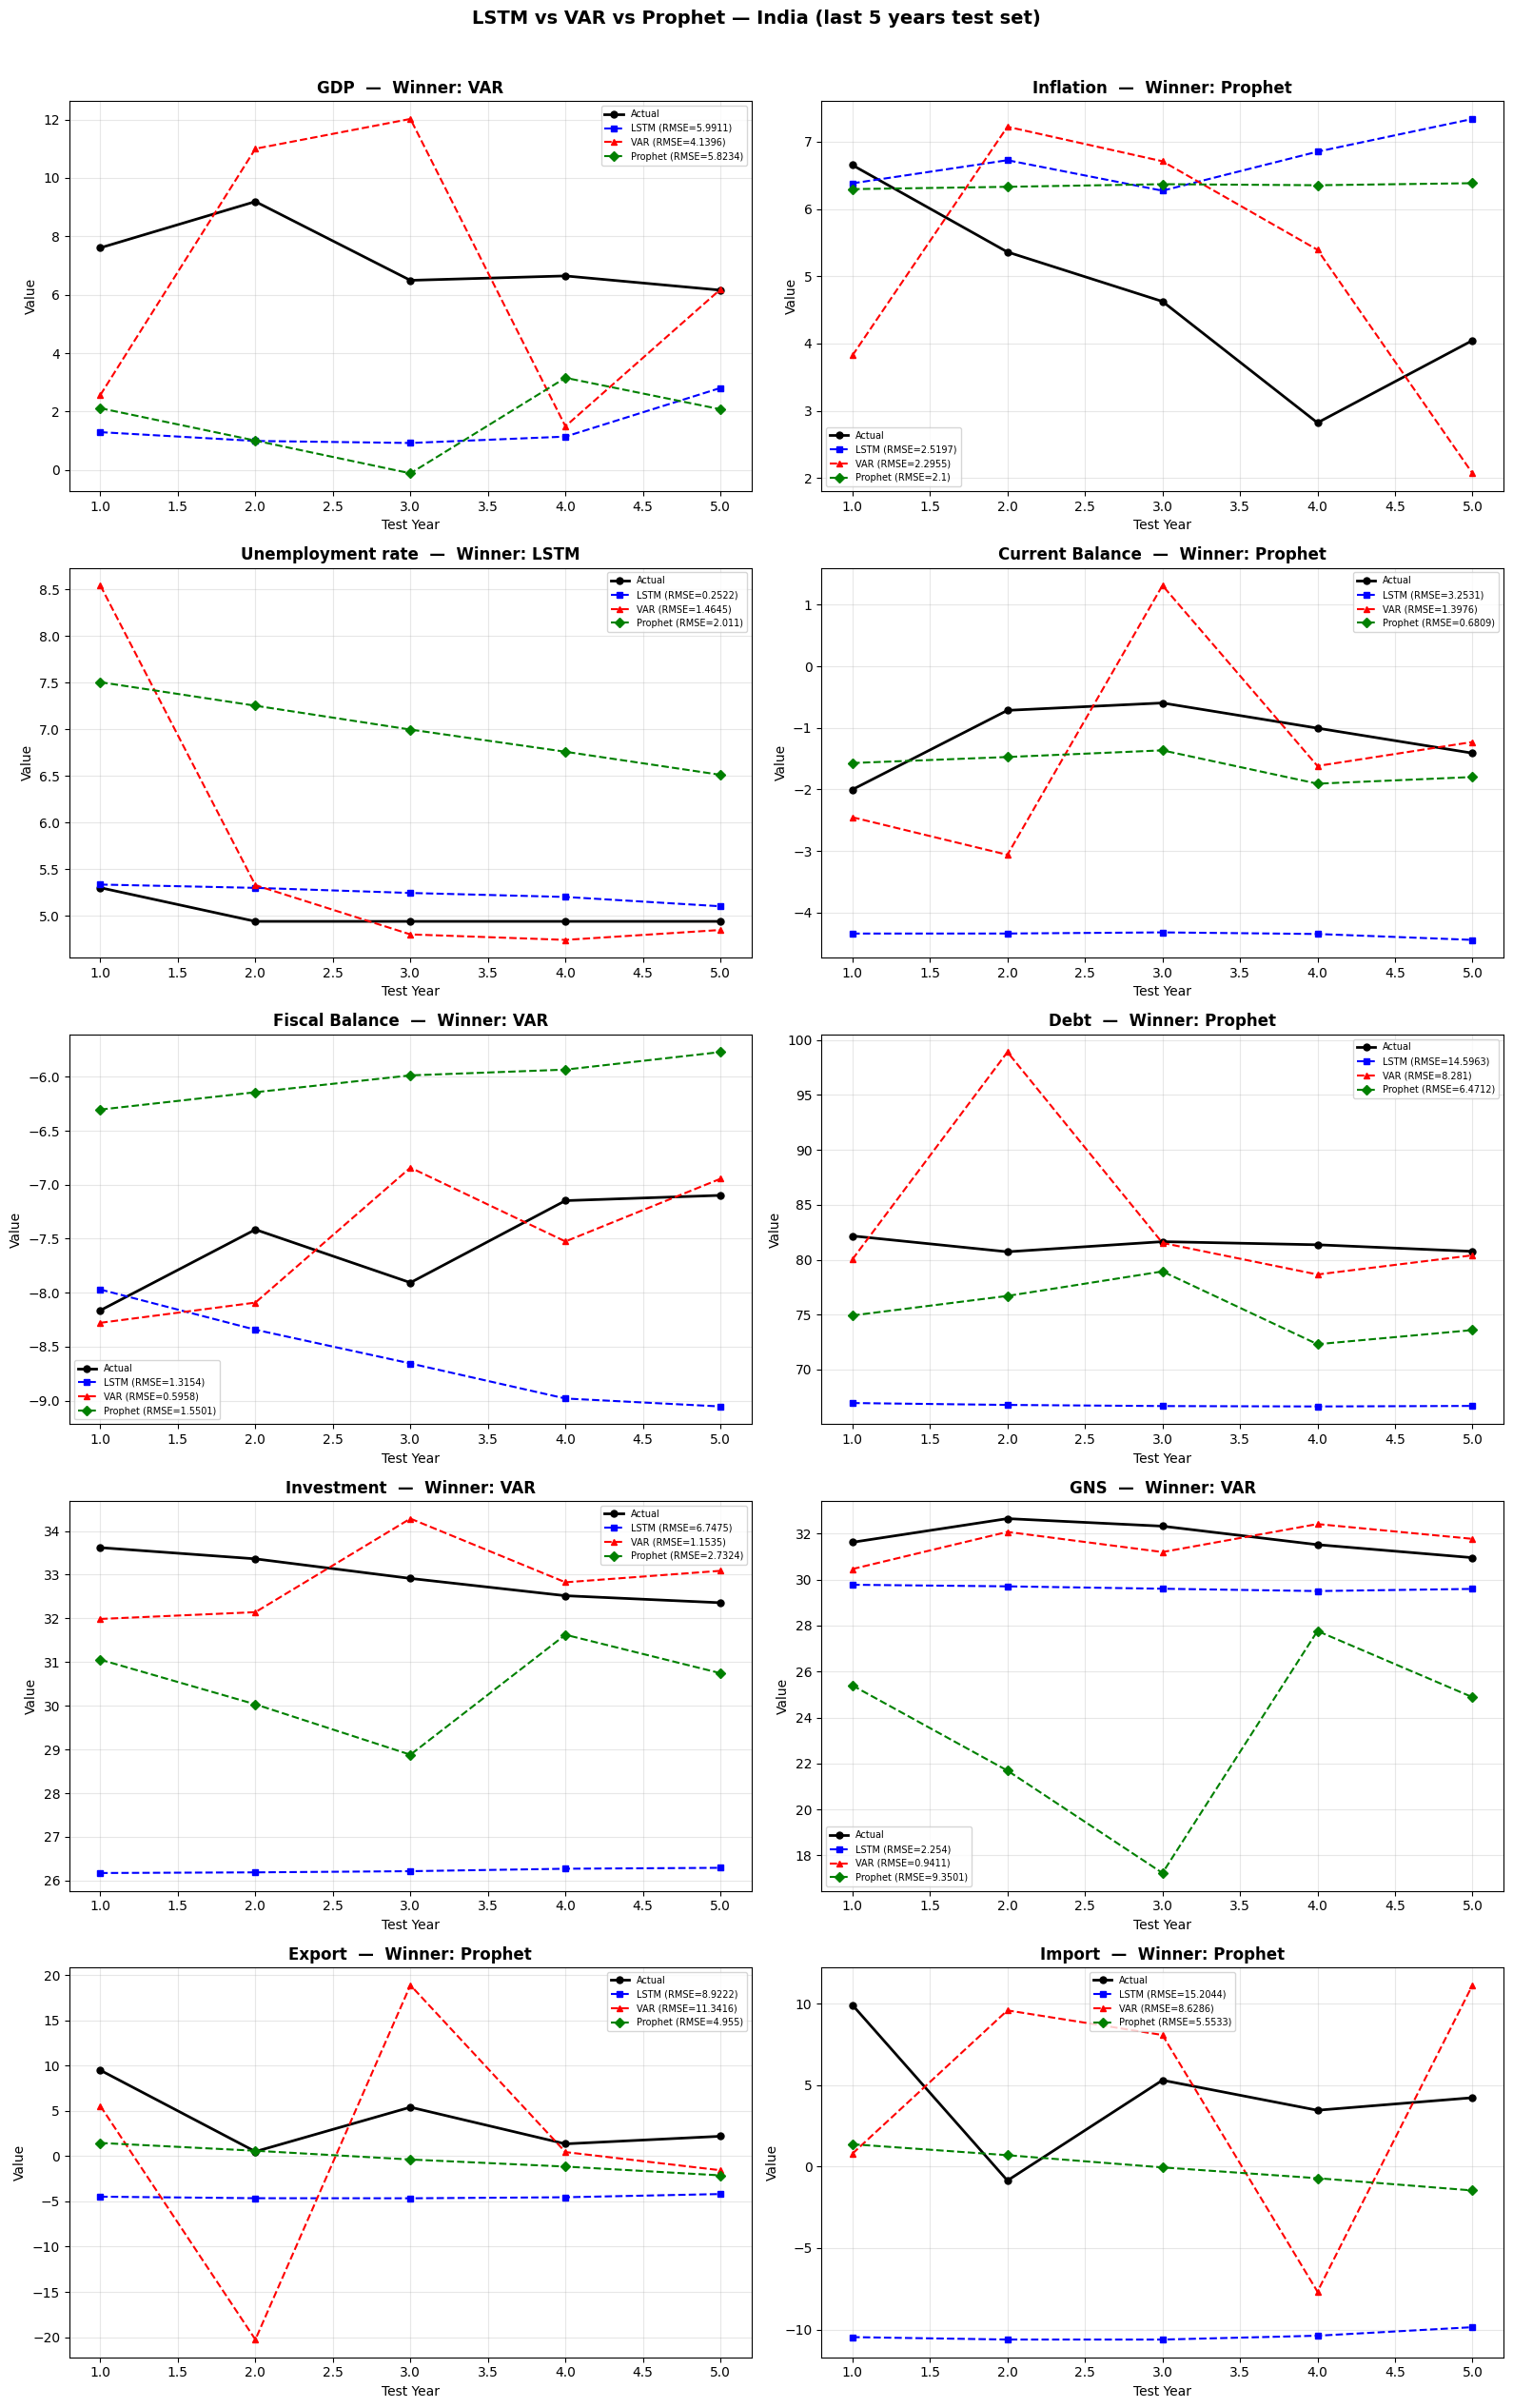

In [22]:
common_mevs = [m for m in ALL_MEVS
               if m in lstm_forecasts and m in var_forecasts and m in prophet_forecasts]

n_cols = 2
n_rows = len(common_mevs) // n_cols + len(common_mevs) % n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes      = np.array(axes).flatten()

for idx, mev in enumerate(common_mevs):
    ax       = axes[idx]
    actual   = lstm_forecasts[mev]['actual']
    x        = np.arange(1, TEST_SIZE + 1)

    ax.plot(x, actual,                            'k-o',  markersize=5, linewidth=2,   label='Actual')
    ax.plot(x, lstm_forecasts[mev]['predicted'],  'b--s', markersize=5, linewidth=1.5, label=f"LSTM (RMSE={lstm_results[mev]['RMSE']})")
    ax.plot(x, var_forecasts[mev]['predicted'],   'r--^', markersize=5, linewidth=1.5, label=f"VAR (RMSE={var_results[mev]['RMSE']})")
    ax.plot(x, prophet_forecasts[mev]['predicted'],'g--D', markersize=5, linewidth=1.5, label=f"Prophet (RMSE={prophet_results[mev]['RMSE']})")

    winner = comparison_df.loc[mev, 'Winner']
    ax.set_title(f'{mev}  —  Winner: {winner}', fontweight='bold')
    ax.set_xlabel('Test Year')
    ax.set_ylabel('Value')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

for j in range(len(common_mevs), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('LSTM vs VAR vs Prophet — India (last 5 years test set)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**RMSE bar chart per MEV**

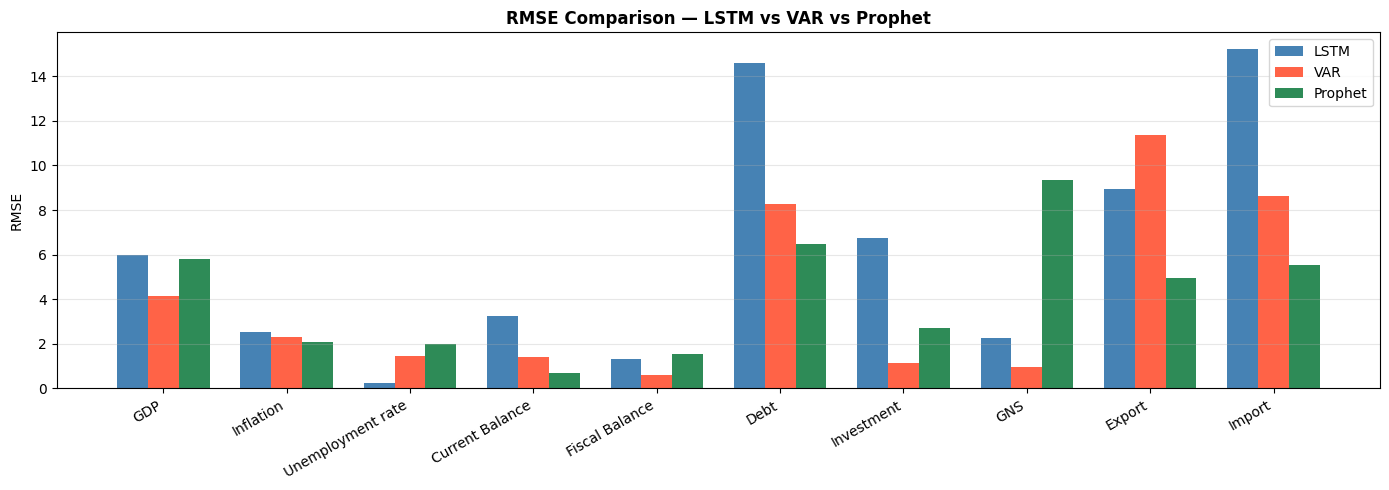

In [23]:
rmse_df = comparison_df[['LSTM RMSE', 'VAR RMSE', 'Prophet RMSE']].dropna(how='all')

x     = np.arange(len(rmse_df))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width, rmse_df['LSTM RMSE'],    width, label='LSTM',    color='steelblue')
ax.bar(x,         rmse_df['VAR RMSE'],     width, label='VAR',     color='tomato')
ax.bar(x + width, rmse_df['Prophet RMSE'], width, label='Prophet', color='seagreen')

ax.set_xticks(x)
ax.set_xticklabels(rmse_df.index, rotation=30, ha='right')
ax.set_ylabel('RMSE')
ax.set_title('RMSE Comparison — LSTM vs VAR vs Prophet', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('rmse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Save comparison results**

In [24]:
comparison_df.to_csv('model_comparison_results.csv')
print('Saved: model_comparison_results.csv')
comparison_df

Saved: model_comparison_results.csv


,LSTM RMSE,VAR RMSE,Prophet RMSE,LSTM MAE,VAR MAE,Prophet MAE,Winner
MEV,,,,,,,
GDP,5.9911,4.1396,5.8234,5.7848,3.5093,5.5694,VAR
Inflation,2.5197,2.2955,2.1000,2.1214,2.2651,1.7880,Prophet
Unemployment rate,0.2522,1.4645,2.0110,0.2244,0.8121,1.9931,LSTM
Current Balance,3.2531,1.3976,0.6809,3.2145,1.1003,0.6499,Prophet
Fiscal Balance,1.3154,0.5958,1.5501,1.1322,0.4780,1.5196,VAR
Debt,14.5963,8.2810,6.4712,14.5878,4.7003,6.0399,Prophet
Investment,6.7475,1.1535,2.7324,6.7270,1.0516,2.4866,VAR
GNS,2.2540,0.9411,9.3501,2.1776,0.9164,8.4165,VAR
Export,8.9222,11.3416,4.9550,8.2888,8.5680,4.1438,Prophet


# End